# 02 EDA Customer Experience
Notebook ini melakukan Exploratory Data Analysis (EDA) awal untuk memahami faktor-faktor yang berhubungan dengan *review score* pelanggan, seperti performa pengiriman, performa penjual, kategori produk, dan wilayah.

**Persona:** Customer Experience Analyst
**Tujuan:** Mengidentifikasi indikasi awal penyebab *review score* yang sulit meningkat.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

raw_path = Path("../data/raw")
processed_path = Path("../data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

## 1. Load Dataset
Membuka file CSV mentah yang dibutuhkan untuk analisis awal.

In [2]:
orders = pd.read_csv(raw_path / "orders.csv")
reviews = pd.read_csv(raw_path / "order_reviews.csv")
order_items = pd.read_csv(raw_path / "order_items.csv")
customers = pd.read_csv(raw_path / "customers.csv")
sellers = pd.read_csv(raw_path / "sellers.csv")
products = pd.read_csv(raw_path / "products.csv")
category_translation = pd.read_csv(raw_path / "category_translation.csv")

datasets = {
    "orders": orders, "reviews": reviews, "items": order_items,
    "customers": customers, "sellers": sellers, "products": products,
    "translation": category_translation
}

for name, df in datasets.items():
    print(f"{name}: {df.shape} columns: {df.columns.tolist()}")

orders: (99441, 8) columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
reviews: (99224, 7) columns: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
items: (112650, 7) columns: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
customers: (99441, 5) columns: ['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
sellers: (3095, 4) columns: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
products: (32951, 9) columns: ['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
translation: (71,

## 2. Parse Datetime
Mengonversi kolom teks menjadi format datetime untuk perhitungan durasi.

In [3]:
# Orders dates
order_dates = ["order_purchase_timestamp", "order_approved_at", 
               "order_delivered_carrier_date", "order_delivered_customer_date", 
               "order_estimated_delivery_date"]
for col in order_dates:
    orders[col] = pd.to_datetime(orders[col], errors="coerce")

# Review dates
review_dates = ["review_creation_date", "review_answer_timestamp"]
for col in review_dates:
    reviews[col] = pd.to_datetime(reviews[col], errors="coerce")

## 3. Prepare Latest Review per Order
Beberapa pesanan memiliki lebih dari satu ulasan. Kita akan mengambil ulasan terakhir untuk menghindari bias penghitungan ganda pada metrik kepuasan.

In [4]:
reviews_raw = reviews.copy()
reviews_latest = (reviews_raw.sort_values(["order_id", "review_answer_timestamp", "review_creation_date"])
                  .drop_duplicates(subset=["order_id"], keep="last"))

print(f"Total reviews raw: {len(reviews_raw)}")
print(f"Unique order_id in reviews: {reviews_raw['order_id'].nunique()}")
print(f"Total reviews latest: {len(reviews_latest)}")
print(f"Orders with >1 review: {(reviews_raw['order_id'].value_counts() > 1).sum()}")

Total reviews raw: 99224
Unique order_id in reviews: 98673
Total reviews latest: 98673
Orders with >1 review: 547


## 4. Build Base Tables
Membangun tabel dasar ditingkat pesanan (*order-level*) dan tingkat item (*item-level*).

In [5]:
# cx_order_base: Satu baris per order
cx_order_base = orders.merge(reviews_latest, on="order_id", how="left")
cx_order_base = cx_order_base.merge(customers, on="customer_id", how="left")

# cx_item_base: Satu baris per item (untuk analisis seller/product)
cx_item_base = cx_order_base.merge(order_items, on="order_id", how="left")
cx_item_base = cx_item_base.merge(sellers, on="seller_id", how="left")
cx_item_base = cx_item_base.merge(products, on="product_id", how="left")
cx_item_base = cx_item_base.merge(category_translation, on="product_category_name", how="left")

# Handing unknown categories
cx_item_base["product_category_name_english"] = cx_item_base["product_category_name_english"].fillna("unknown")

## 5. Feature Engineering
Membuat fitur baru untuk analisis periode, skor rendah, dan durasi pengiriman.

In [6]:
def add_features(df):
    # Review traits
    df["review_month"] = df["review_creation_date"].dt.to_period("M")
    df["is_low_rating_2"] = df["review_score"] <= 2
    df["is_low_rating_3"] = df["review_score"] <= 3
    
    # Delivery traits
    df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
    df["delay_days"] = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days
    
    # Status
    conditions = [
        (df["delay_days"] > 0),
        (df["delay_days"] <= 0),
        (df["order_delivered_customer_date"].isna())
    ]
    df["delivery_status"] = np.select(conditions, ["late", "on_time_or_early", "unknown"], default="unknown")
    
    # Buckets
    bucket_cond = [
        (df["delay_days"] <= 0),
        (df["delay_days"].between(1, 3)),
        (df["delay_days"].between(4, 7)),
        (df["delay_days"].between(8, 14)),
        (df["delay_days"] > 14),
        (df["delay_days"].isna())
    ]
    bucket_labels = ["early_or_on_time", "late_1_3_days", "late_4_7_days", "late_8_14_days", "late_15plus_days", "unknown"]
    df["delay_bucket"] = np.select(bucket_cond, bucket_labels, default="unknown")
    
    return df

cx_order_base = add_features(cx_order_base)
cx_item_base = add_features(cx_item_base)

## 6. EDA Review Score
Distribusi ulasan pelanggan secara keseluruhan.

Average Review Score: 4.09
Low Rating Rate (<=2): 14.58%
Low Rating Rate (<=3): 22.75%


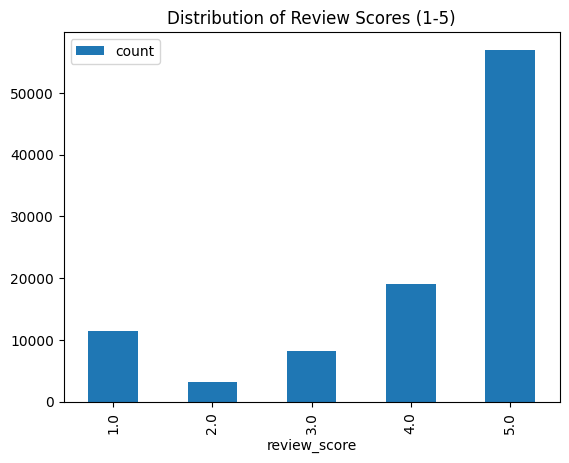

,count,percentage
review_score,,
1.0,11363,11.515815
2.0,3131,3.173107
3.0,8133,8.242376
4.0,19038,19.294032
5.0,57008,57.774670


In [7]:
review_dist = cx_order_base["review_score"].value_counts(normalize=True).sort_index() * 100
review_counts = cx_order_base["review_score"].value_counts().sort_index()

review_distribution = pd.DataFrame({
    "count": review_counts,
    "percentage": review_dist
})

avg_score = cx_order_base["review_score"].mean()
low_2_rate = cx_order_base["is_low_rating_2"].mean() * 100
low_3_rate = cx_order_base["is_low_rating_3"].mean() * 100

print(f"Average Review Score: {avg_score:.2f}")
print(f"Low Rating Rate (<=2): {low_2_rate:.2f}%")
print(f"Low Rating Rate (<=3): {low_3_rate:.2f}%")

review_distribution.plot(kind="bar", y="count", title="Distribution of Review Scores (1-5)")
plt.show()

review_distribution

## 7. Monthly Review Trend
Menganalisis tren kepuasan pelanggan dari waktu ke waktu.

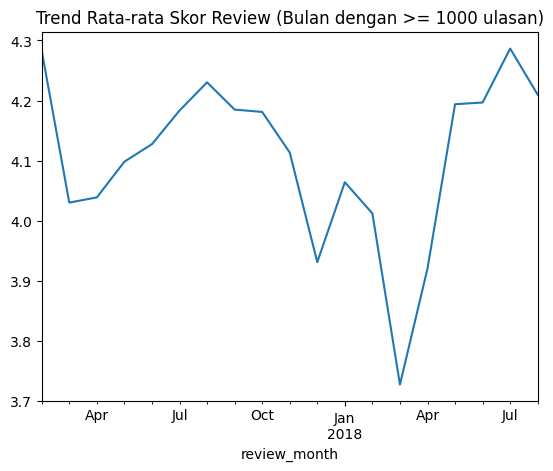

Trend Analysis Stats (Valid Months):
count    19.000000
mean      4.105787
std       0.140332
min       3.726766
25%       4.034276
50%       4.127278
75%       4.195271
max       4.286529
Name: avg_review_score, dtype: float64


In [8]:
monthly_trend = cx_order_base.groupby("review_month").agg(
    review_count=("review_score", "count"),
    avg_review_score=("review_score", "mean"),
    low_rating_2_rate=("is_low_rating_2", "mean"),
    low_rating_3_rate=("is_low_rating_3", "mean")
)

# Filter months with sufficient data
valid_trend = monthly_trend[monthly_trend["review_count"] >= 1000]

valid_trend["avg_review_score"].plot(title="Trend Rata-rata Skor Review (Bulan dengan >= 1000 ulasan)")
plt.show()

print(f"Trend Analysis Stats (Valid Months):")
print(valid_trend["avg_review_score"].describe())

## 8. EDA Delivery vs Review
Mengevaluasi asosiasi antara kecepatan pengiriman dan skor ulasan.

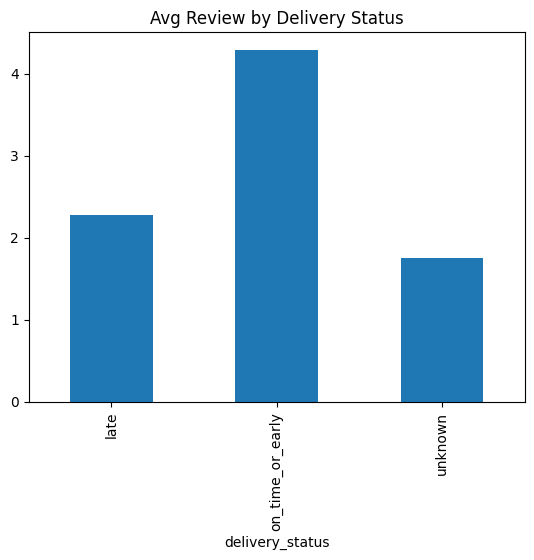

,order_count,avg_review_score,low_rating_2_rate
delivery_status,,,
late,6535,2.270605,0.609487
on_time_or_early,89941,4.290247,0.092205
unknown,2965,1.748505,0.748061


In [9]:
delivery_summary = cx_order_base.groupby("delivery_status").agg(
    order_count=("order_id", "count"),
    avg_review_score=("review_score", "mean"),
    low_rating_2_rate=("is_low_rating_2", "mean")
)

delay_bucket_summary = cx_order_base.groupby("delay_bucket").agg(
    order_count=("order_id", "count"),
    avg_review_score=("review_score", "mean"),
    low_rating_2_rate=("is_low_rating_2", "mean")
)

delivery_summary["avg_review_score"].plot(kind="bar", title="Avg Review by Delivery Status")
plt.show()

delivery_summary

## 9. EDA Seller Performance
Mengidentifikasi penjual dengan tingkat kepuasan rendah (minimal 30 pesanan).

In [10]:
seller_summary = cx_item_base.groupby(["seller_id", "seller_city", "seller_state"]).agg(
    order_count=("order_id", "nunique"),
    avg_review_score=("review_score", "mean"),
    low_rating_2_rate=("is_low_rating_2", "mean"),
    late_rate=("delivery_status", lambda x: (x == "late").mean()),
    avg_delay_days=("delay_days", "mean"),
    low_rating_count=("is_low_rating_2", "sum")
).reset_index()

# Filter low volume
problematic_sellers = seller_summary[seller_summary["order_count"] >= 30].sort_values("low_rating_2_rate", ascending=False).head(15)
problematic_sellers

,seller_id,seller_city,seller_state,order_count,avg_review_score,low_rating_2_rate,late_rate,avg_delay_days,low_rating_count
333,1ca7077d890b907f89be8c954a02686a,santana de parnaiba,SP,115,2.198529,0.649635,0.138686,-6.858268,89
554,2eb70248d66e0e3ef83659f71b244378,campinas,SP,202,2.716346,0.490566,0.108491,-10.121827,104
1178,602044f2c16190c2c6e45eb35c2e21cb,ibitinga,SP,50,2.892857,0.456140,0.192982,-8.127273,26
1747,8e6d7754bc7e0f22c96d255ebda59eba,sao jose dos campos,SP,85,2.976923,0.453846,0.100000,-6.294574,59
1832,95f83f51203c626648c875dd41874c7f,borda da mata,MG,52,3.208955,0.447761,0.029851,-14.261538,30
2257,bbad7e518d7af88a0897397ffdca1979,sao paulo,SP,69,3.035714,0.447059,0.223529,-7.023810,38
2004,a49928bcdf77c55c6d6e05e09a9b4ca5,sao paulo,SP,98,2.952830,0.433962,0.207547,-4.586538,46
1032,54965bbe3e4f07ae045b90b0b8541f52,foz do iguacu,PR,78,2.938272,0.430233,0.302326,-2.395062,37
1846,972d0f9cf61b499a4812cf0bfa3ad3c4,brusque,SC,83,2.964286,0.420455,0.113636,-9.755814,37
2667,dc8798cbf453b7e0f98745e396cc5616,sao paulo,SP,41,3.117647,0.411765,0.058824,-9.395349,21


## 10. EDA Product Category
Analisis kepuasan pelanggan berdasarkan kategori produk (minimal 50 pesanan).

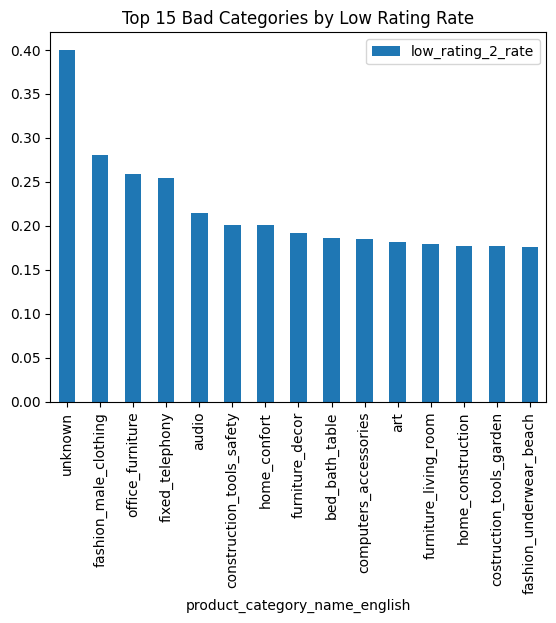

,product_category_name_english,order_count,avg_review_score,low_rating_2_rate,late_rate,avg_delay_days,low_rating_count
70,unknown,2248,3.157028,0.400083,0.048293,-11.380372,961
30,fashion_male_clothing,112,3.641221,0.280303,0.053030,-12.712000,37
57,office_furniture,1273,3.491950,0.259018,0.078652,-11.845923,438
34,fixed_telephony,217,3.681992,0.253788,0.037879,-14.717647,67
4,audio,350,3.833333,0.214286,0.115385,-10.149171,78
19,construction_tools_safety,167,3.844560,0.201031,0.025773,-12.387978,39
47,home_confort,397,3.831019,0.200461,0.092166,-9.811189,87
39,furniture_decor,6449,3.906788,0.191625,0.068874,-12.399510,1597
7,bed_bath_table,9417,3.898470,0.186415,0.069276,-11.656167,2072
15,computers_accessories,6689,3.932537,0.184490,0.063370,-12.419861,1444


In [11]:
category_summary = cx_item_base.groupby("product_category_name_english").agg(
    order_count=("order_id", "nunique"),
    avg_review_score=("review_score", "mean"),
    low_rating_2_rate=("is_low_rating_2", "mean"),
    late_rate=("delivery_status", lambda x: (x == "late").mean()),
    avg_delay_days=("delay_days", "mean"),
    low_rating_count=("is_low_rating_2", "sum")
).reset_index()

# Filter low volume
top_bad_categories = category_summary[category_summary["order_count"] >= 50].sort_values("low_rating_2_rate", ascending=False).head(15)

top_bad_categories.plot(kind="bar", x="product_category_name_english", y="low_rating_2_rate", title="Top 15 Bad Categories by Low Rating Rate")
plt.show()

top_bad_categories

## 11. EDA Region
Melihat performa pelayanan berdasarkan wilayah pelanggan dan penjual.

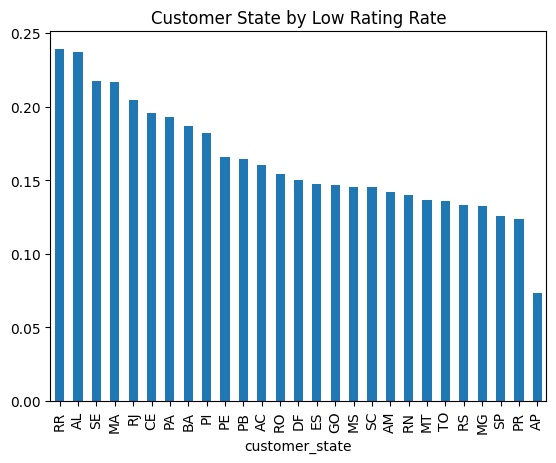

In [12]:
customer_region_summary = cx_order_base.groupby("customer_state").agg(
    order_count=("order_id", "count"),
    avg_review_score=("review_score", "mean"),
    low_rating_2_rate=("is_low_rating_2", "mean"),
    late_rate=("delivery_status", lambda x: (x == "late").mean())
)

seller_region_summary = cx_item_base.groupby("seller_state").agg(
    order_count=("order_id", "nunique"),
    avg_review_score=("review_score", "mean"),
    low_rating_2_rate=("is_low_rating_2", "mean"),
    late_rate=("delivery_status", lambda x: (x == "late").mean())
)

customer_region_summary.sort_values("low_rating_2_rate", ascending=False)["low_rating_2_rate"].plot(kind="bar", title="Customer State by Low Rating Rate")
plt.show()

## 12. Initial Findings
1. **Review Distribution**: Mayoritas pelanggan memberikan rating 5, namun terdapat porsi rating rendah (<=2) yang signifikan.
2. **Review Trend**: Terlihat ada fluktuasi namun rata-rata skor cenderung tidak menunjukkan tren kenaikan yang konsisten di periode akhir.
3. **Delivery Impact**: Terdapat asosiasi awal antara keterlambatan pengiriman (`late`) dengan skor ulasan yang jauh lebih rendah dibandingkan pengiriman tepat waktu.
4. **Seller & Category**: Beberapa penjual dan kategori produk tertentu memiliki tingkat ulasan rendah yang jauh di atas rata-rata platform.
5. **Region**: Perbedaan tingkat kepuasan terlihat antar negara bagian, yang mungkin berkaitan dengan infrastruktur logistik.

Insight ini akan diverifikasi lebih lanjut pada tahap Root Cause Analysis dan Dashboard Planning.

## 13. Export Data
Menyimpan hasil agregasi untuk dokumentasi dan kebutuhan dashboard.

In [13]:
review_distribution.to_csv(processed_path / "review_distribution.csv")
monthly_trend.to_csv(processed_path / "monthly_review_trend.csv")
delivery_summary.to_csv(processed_path / "delivery_status_summary.csv")
delay_bucket_summary.to_csv(processed_path / "delay_bucket_summary.csv")
seller_summary.to_csv(processed_path / "seller_summary.csv")
category_summary.to_csv(processed_path / "category_summary.csv")
customer_region_summary.to_csv(processed_path / "customer_region_summary.csv")
seller_region_summary.to_csv(processed_path / "seller_region_summary.csv")

# Base tables (Optional - size check recommended)
cx_order_base.to_csv(processed_path / "customer_experience_order_base.csv", index=False)
# cx_item_base.to_csv(processed_path / "customer_experience_item_base.csv", index=False)